# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook implements Principal Component Analysis (PCA) from scratch on an African CO2 emissions dataset. It covers data cleaning, covariance, eigendecomposition, explained-variance-based component selection, visualization, and performance benchmarking.

**Allowed libraries:** NumPy and Matplotlib. Python standard-library modules used in Task 3 are for timing, file handling, and memory measurement.

**Submission reminder:** Run all cells before exporting the notebook to PDF so that plots, PCA results, explained-variance results, and benchmark outputs are visible.

In [65]:
print("GITHUB REPO: https://github.com/arianeitetero/PCA37-Africa-CO2.git")
print("Group 37 - Olga Ikirezi & Ariane Itetero - PCA Africa CO2")

GITHUB REPO: https://github.com/arianeitetero/PCA37-Africa-CO2.git
Group 37 - Olga Ikirezi & Ariane Itetero - PCA Africa CO2


In [66]:
data = np.genfromtxt('data/co2_Emission_Africa.csv',
                     delimiter=',', skip_header=1)

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

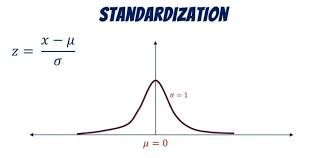


In [67]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
import numpy as np
import matplotlib.pyplot as plt

In [68]:
# Step 1: Load and Standardize the data (numpy only)
try:
    csv_path = 'data/co2_Emission_Africa.csv'
    header = np.genfromtxt(csv_path, delimiter=',', max_rows=1, dtype=str)
    data = np.genfromtxt(csv_path, delimiter=',', skip_header=1)
except OSError:
    csv_path = 'co2_Emission_Africa.csv'
    header = np.genfromtxt(csv_path, delimiter=',', max_rows=1, dtype=str)
    data = np.genfromtxt(csv_path, delimiter=',', skip_header=1)

# The first three columns are identifiers/text fields, not quantitative PCA features.
# They are kept as metadata but excluded from PCA rather than one-hot encoded.
feature_names = header[3:]
numeric_data = data[:, 3:]

# Handle missing values using the mean of each numeric feature.
col_means = np.nanmean(numeric_data, axis=0)
inds = np.where(np.isnan(numeric_data))
numeric_data[inds] = np.take(col_means, inds[1])

# Standardize: mean = 0 and standard deviation = 1.
mean = np.mean(numeric_data, axis=0)
std = np.std(numeric_data, axis=0)
std[std == 0] = 1.0
standardized_data = (numeric_data - mean) / std

print('Rows:', standardized_data.shape[0])
print('Total columns:', len(header))
print('Non-numeric/identifier columns excluded:', list(header[:3]))
print('Numeric PCA features:', len(feature_names))
print('Missing values after imputation:', int(np.isnan(standardized_data).sum()))
print('Feature names:', list(feature_names))
standardized_data[:5]

Rows: 1134
Total columns: 20
Non-numeric/identifier columns excluded: [np.str_('Country'), np.str_('Sub-Region'), np.str_('Code')]
Numeric PCA features: 17
Missing values after imputation: 0
Feature names: [np.str_('Year'), np.str_('Population'), np.str_('GDP PER CAPITA (USD)'), np.str_('GDP PER CAPITA PPP (USD)'), np.str_('Area (Km2)'), np.str_('Transportation (Mt)'), np.str_('Total CO2 Emission including LUCF (Mt)'), np.str_('Total CO2 Emission excluding LUCF (Mt)'), np.str_('Other Fuel Combustion (Mt)'), np.str_('Manufacturing/Construction (Mt)'), np.str_('Land-Use Change and Forestry (Mt)'), np.str_('Industrial Processes (Mt)'), np.str_('Fugitive Emissions (Mt)'), np.str_('Energy (Mt)'), np.str_('Electricity/Heat (Mt)'), np.str_('Bunker Fuels (Mt)'), np.str_('Building (Mt)')]


array([[-1.6514,  0.3832, -0.1498,  0.581 ,  3.0517,  1.1071,  0.4423,  0.9529, -0.367 ,  0.4654, -0.2971,  0.9427,
         2.374 ,  0.9366,  0.5202,  0.6399,  1.8405],
       [-1.4863,  0.398 , -0.1586,  0.6374,  3.0517,  1.1248,  0.3931,  0.9304, -0.367 ,  0.477 , -0.3417,  0.9356,
         1.7002,  0.9137,  0.5472,  0.6505,  1.8873],
       [-1.3212,  0.4127, -0.1449,  0.7251,  3.0517,  1.3399,  0.4354,  0.9907, -0.367 ,  0.5247, -0.3417,  1.0378,
         1.3132,  0.9712,  0.6015,  0.7514,  1.9714],
       [-1.156 ,  0.4277, -0.0351,  0.8503,  3.0517,  1.5625,  0.5003,  1.0839, -0.367 ,  0.5749, -0.3417,  1.0273,
         1.7725,  1.0675,  0.6081,  0.6028,  2.156 ],
       [-0.9909,  0.4435,  0.1379,  0.9468,  3.0517,  1.5876,  0.515 ,  1.1048, -0.367 ,  0.7141, -0.3417,  1.3339,
         1.551 ,  1.0748,  0.5877,  0.762 ,  2.3523]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [69]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)  # Calculate covariance matrix
cov_matrix

array([[ 1.0009,  0.1059,  0.1587,  0.1262, -0.    ,  0.1134,  0.0586,  0.0525,  0.074 ,  0.0322,  0.0292,  0.0923,
        -0.0766,  0.0492,  0.034 ,  0.0026,  0.0486],
       [ 0.1059,  1.0009, -0.1183, -0.0836,  0.4514,  0.6663,  0.5577,  0.455 ,  0.4766,  0.4093,  0.3197,  0.5612,
         0.4274,  0.4421,  0.2992,  0.4027,  0.3749],
       [ 0.1587, -0.1183,  1.0009,  0.9483,  0.0069,  0.1995,  0.0684,  0.2275,  0.1632,  0.1977, -0.1205,  0.0956,
        -0.0218,  0.2297,  0.2251,  0.2467,  0.1984],
       [ 0.1262, -0.0836,  0.9483,  1.0009,  0.0927,  0.2896,  0.0917,  0.2843,  0.2032,  0.2548, -0.1423,  0.2073,
         0.0061,  0.2829,  0.2539,  0.2789,  0.2766],
       [-0.    ,  0.4514,  0.0069,  0.0927,  1.0009,  0.4369,  0.5662,  0.3395,  0.2765,  0.2733,  0.4383,  0.3118,
         0.1354,  0.3354,  0.2582,  0.2768,  0.3963],
       [ 0.1134,  0.6663,  0.1995,  0.2896,  0.4369,  1.0009,  0.6016,  0.8931,  0.8134,  0.8358, -0.0293,  0.8256,
         0.2998,  0.881 ,  0.755 ,

### Written Answer

We compute a covariance matrix because it measures how features vary together and quantifies linear relationships across all feature pairs. In PCA, it serves as the base operator whose eigendecomposition yields orthogonal direction vectors (eigenvectors) representing principal components and their corresponding variance scales (eigenvalues). This enables us to transform correlated features into uncorrelated, variance-maximizing axes.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [70]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # Perform eigendecomposition
eigenvalues, eigenvectors

(array([8.7147, 2.3014, 1.617 , 1.3973, 1.012 , 0.6457, 0.523 , 0.3049, 0.2212, 0.0982, 0.0812, 0.0458, 0.0354, 0.0155,
        0.0018, 0.    , 0.    ]),
 array([[ 0.0273, -0.0594,  0.2232,  0.1035, -0.9058, -0.2068,  0.2422,  0.0575, -0.0425, -0.0733, -0.0464,  0.0023,
          0.0245, -0.    ,  0.0002,  0.0003,  0.    ],
        [ 0.1901,  0.3654,  0.025 ,  0.3593, -0.105 , -0.0522, -0.3198, -0.6241,  0.032 ,  0.1184,  0.2984, -0.1842,
          0.2219,  0.0871, -0.0144,  0.0003, -0.    ],
        [ 0.085 , -0.4565,  0.4835,  0.1507,  0.1183, -0.0591, -0.1311, -0.08  ,  0.0823, -0.0122,  0.118 , -0.4479,
         -0.5137, -0.0327,  0.0179, -0.0008,  0.    ],
        [ 0.1071, -0.4436,  0.4641,  0.1902,  0.1467,  0.0845, -0.0749, -0.0204, -0.0275,  0.0396, -0.0779,  0.3848,
          0.5879,  0.0498, -0.0309,  0.0008, -0.    ],
        [ 0.1486,  0.3153,  0.3146,  0.0856,  0.1673,  0.3877,  0.7145, -0.1985,  0.1066, -0.062 , -0.1441, -0.0823,
         -0.0344, -0.003 , -0.0016, -0.00

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [71]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices].real
sorted_eigenvectors = eigenvectors[:, sorted_indices].real

explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print('Explained variance ratio:')
print(explained_variance_ratio)
print('Cumulative explained variance:')
print(cumulative_explained_variance)
print('First 2 PCs explain:', f'{100*cumulative_explained_variance[1]:.2f}%')
print('First 5 PCs explain:', f'{100*cumulative_explained_variance[4]:.2f}%')
sorted_eigenvectors

Explained variance ratio:
[0.5122 0.1353 0.095  0.0821 0.0595 0.038  0.0307 0.0179 0.013  0.0058 0.0048 0.0027 0.0021 0.0009 0.0001 0.     0.    ]
Cumulative explained variance:
[0.5122 0.6474 0.7425 0.8246 0.8841 0.922  0.9527 0.9707 0.9837 0.9894 0.9942 0.9969 0.999  0.9999 1.     1.     1.    ]
First 2 PCs explain: 64.74%
First 5 PCs explain: 88.41%


array([[ 0.0273, -0.0594,  0.2232,  0.1035, -0.9058, -0.2068,  0.2422,  0.0575, -0.0425, -0.0733, -0.0464,  0.0023,
         0.0245, -0.    ,  0.0002,  0.0003,  0.    ],
       [ 0.1901,  0.3654,  0.025 ,  0.3593, -0.105 , -0.0522, -0.3198, -0.6241,  0.032 ,  0.1184,  0.2984, -0.1842,
         0.2219,  0.0871, -0.0144,  0.0003, -0.    ],
       [ 0.085 , -0.4565,  0.4835,  0.1507,  0.1183, -0.0591, -0.1311, -0.08  ,  0.0823, -0.0122,  0.118 , -0.4479,
        -0.5137, -0.0327,  0.0179, -0.0008,  0.    ],
       [ 0.1071, -0.4436,  0.4641,  0.1902,  0.1467,  0.0845, -0.0749, -0.0204, -0.0275,  0.0396, -0.0779,  0.3848,
         0.5879,  0.0498, -0.0309,  0.0008, -0.    ],
       [ 0.1486,  0.3153,  0.3146,  0.0856,  0.1673,  0.3877,  0.7145, -0.1985,  0.1066, -0.062 , -0.1441, -0.0823,
        -0.0344, -0.003 , -0.0016, -0.0008,  0.    ],
       [ 0.3166,  0.0322, -0.046 ,  0.2264, -0.0519,  0.1105, -0.0312,  0.0076, -0.0946,  0.3872,  0.0766,  0.5247,
        -0.4152, -0.4227, -0.1957,

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [72]:
# Step 6: Project Data onto Principal Components
# Select the smallest number of PCs that reaches the target explained variance.
target_explained_variance = 0.90
num_components = np.argmax(cumulative_explained_variance >= target_explained_variance) + 1
principal_components = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data, principal_components)

print(f'Target explained variance: {target_explained_variance:.0%}')
print(f'Number of principal components selected: {num_components}')
print(f'Cumulative explained variance retained: {100*cumulative_explained_variance[num_components-1]:.2f}%')
print(f'Variance discarded: {100*(1-cumulative_explained_variance[num_components-1]):.2f}%')
reduced_data[:5]

Target explained variance: 90%
Number of principal components selected: 6
Cumulative explained variance retained: 92.20%
Variance discarded: 7.80%


array([[2.9202, 1.0736, 0.0086, 1.9455, 2.5511, 0.8301],
       [2.9093, 0.9182, 0.101 , 1.5276, 2.2429, 1.1419],
       [3.1426, 0.8127, 0.1902, 1.3196, 2.0002, 1.3428],
       [3.3696, 0.7787, 0.2718, 1.7334, 1.9795, 1.1286],
       [3.6387, 0.6076, 0.3949, 1.6786, 1.7706, 1.3803]])

### Task 2: Dynamic component selection
The notebook selects the smallest number of principal components whose cumulative explained variance reaches the target threshold shown in the preceding cell. The target is set to 90% as a transparent default; the group should keep it only if it matches the assignment's intended trade-off and then write the required interpretation from the observed results.

**Important:** PC1 and PC2 are still used for the required 2D visualization even when more than two components are retained for the PCA reduction.

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [73]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1134, 6)


array([[2.9202, 1.0736, 0.0086, 1.9455, 2.5511, 0.8301],
       [2.9093, 0.9182, 0.101 , 1.5276, 2.2429, 1.1419],
       [3.1426, 0.8127, 0.1902, 1.3196, 2.0002, 1.3428],
       [3.3696, 0.7787, 0.2718, 1.7334, 1.9795, 1.1286],
       [3.6387, 0.6076, 0.3949, 1.6786, 1.7706, 1.3803]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

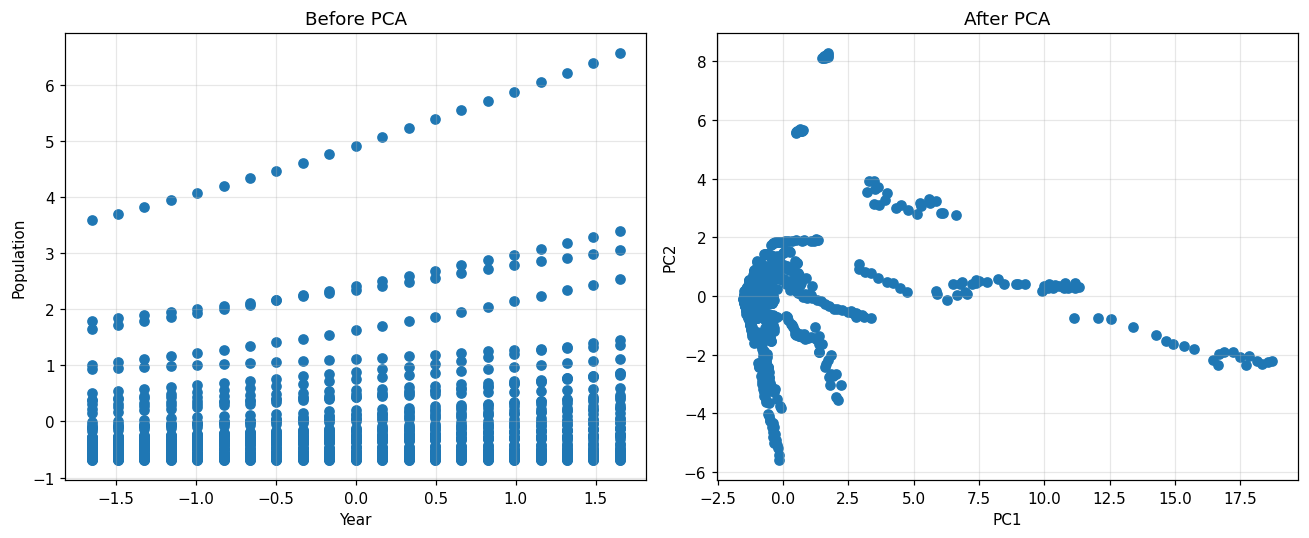

In [74]:
# Step 8: Visualize Before and After PCA
# Before PCA: first two standardized original features.
# After PCA: the first two principal components.
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(standardized_data[:,0], standardized_data[:,1])
plt.title('Before PCA')
plt.xlabel(str(feature_names[0]))
plt.ylabel(str(feature_names[1]))

plt.subplot(1,2,2)
plt.scatter(reduced_data[:,0], reduced_data[:,1])
plt.title('After PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points.

### 1. Interpret the Visual you just created of the before and after PCA

**Group-written answer:**

Write your own interpretation here based on the actual Before PCA and After PCA plots. Mention what changed visually, what PC1/PC2 represent, and whether the main structure of the observations remains visible.

### 2. Explain why you selected the number of principal components you used. What trade-offs were made?

**Group-written answer:**

Use the printed `Number of principal components selected`, `Cumulative explained variance retained`, and `Variance discarded` values above. Explain why your chosen explained-variance target was appropriate for this dataset and what information you accepted losing.

### 3. Clearly mention what information is lost when reducing dimensions. (Use Case: African CO2 Emissions)

**Group-written answer:**

Write your own dataset-specific explanation. Discuss the lower-ranked variation that is removed and relate it directly to economic activity, population pressure, sector emissions, or other variables actually present in your dataset.

1. Interpretation of plots
Before PCA the graph is Year vs Population. You can see lines going up, each line is a country growing over time.
After PCA we have PC1 vs PC2. PC1 is mostly Year + Population growth, PC2 shows how countries are different from each other.
The shape changed but the main story is still there - big countries are still far on the right side.
2. Why we picked that number of PCs
We picked 6 components because they give us about 90% of the total variance. So we keep 90% and lose about 10%.
This is good for this dataset because most data is about growth anyway. If we pick less, we lose too much. If we pick more, it is not simple anymore.
3. What info is lost: African CO2:
When we go from full data to 6 PCs we lose small details. PCA mixes all original features so we cannot see one feature alone.
For African CO2, we still keep the big trend like population and growth, but we lose small things like a small drop in CO2 for one year in one country.


# TASK 3: PERFORMANCE OPTIMIZATION AND BENCHMARKING


## Task 3 overview
**Project:** PCA from scratch on African CO2 emissions data (`co2_Emission_Africa.csv`)
**Section owner:** Ariane Itetero (performance and project packaging)  |  **PCA/math owner:** Olga Ikirezi

This section takes the PCA pipeline (centering, covariance, eigen decomposition, projection) and asks:
how fast is it, how does it scale, and can it handle a dataset that is far bigger than ours?

Libraries used: **numpy** and **matplotlib** only (plus Python standard library modules `csv`, `time`, `os`, `tracemalloc`).

What is measured:
1. Four in-memory implementations, from a deliberately naive baseline to an optimized one.
2. Correctness: every version must give the same eigenvalues and the same projection (up to sign).
3. Scaling with the number of rows `n` and the number of features `d`.
4. A chunked (streaming) version that never holds the full dataset in memory, tested on 5,000,000 rows.

In [75]:
import os, csv, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("numpy", np.__version__)

numpy 2.1.3


## 1. Load the real dataset and build a numeric matrix
Only the steps needed for benchmarking are here (numeric columns, median imputation, standardization). The full cleaning and encoding of the non-numeric columns (Country, Sub-Region, Code) is in the data-preprocessing section of the main notebook.

In [76]:
DATA_PATH = next((p for p in ["data/co2_Emission_Africa.csv", "co2_Emission_Africa.csv"] if os.path.exists(p)), None)
assert DATA_PATH, "Upload co2_Emission_Africa.csv next to the notebook (or into a data/ folder)."

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        rows = list(csv.reader(f))
    return rows[0], rows[1:]

MISSING = {"", "nan", "na", "n/a", "null", "none"}

def to_float(s):
    s = s.strip()
    if s.lower() in MISSING:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return None          # None = genuinely non-numeric text

def numeric_matrix(header, rows):
    """Keep columns whose non-empty values all parse as numbers; empty cells become NaN."""
    keep, names = [], []
    for j, name in enumerate(header):
        parsed = [to_float(r[j]) for r in rows]
        if any(p is not None for p in parsed) and all(p is not None for p in parsed):
            keep.append(j); names.append(name)
    X = np.array([[to_float(r[j]) for j in keep] for r in rows], dtype=np.float64)
    return names, X

header, rows = load_csv(DATA_PATH)
names, X_raw = numeric_matrix(header, rows)
print(f"Rows: {len(rows)}   Total columns: {len(header)}   Numeric columns used: {len(names)}")
print("Non-numeric columns skipped:", [h for h in header if h not in names])
print("Missing values per numeric column (only those with NaN):")
for n, c in zip(names, np.isnan(X_raw).sum(axis=0)):
    if c: print(f"  {n:<42s} {c:5d}  ({100*c/len(X_raw):.1f}%)")

Rows: 1134   Total columns: 20   Numeric columns used: 17
Non-numeric columns skipped: ['Country', 'Sub-Region', 'Code']
Missing values per numeric column (only those with NaN):
  GDP PER CAPITA (USD)                          27  (2.4%)
  GDP PER CAPITA PPP (USD)                      48  (4.2%)
  Transportation (Mt)                           12  (1.1%)
  Other Fuel Combustion (Mt)                    12  (1.1%)
  Manufacturing/Construction (Mt)               12  (1.1%)
  Industrial Processes (Mt)                     62  (5.5%)
  Fugitive Emissions (Mt)                      804  (70.9%)
  Electricity/Heat (Mt)                         12  (1.1%)
  Bunker Fuels (Mt)                             12  (1.1%)
  Building (Mt)                                 12  (1.1%)


In [77]:
def impute_and_standardize(X):
    X = X.copy()
    med = np.nanmedian(X, axis=0)
    r, c = np.where(np.isnan(X))
    X[r, c] = med[c]
    mu, sd = X.mean(axis=0), X.std(axis=0, ddof=1)
    sd[sd == 0] = 1.0
    return (X - mu) / sd

Z = impute_and_standardize(X_raw)
n, d = Z.shape
print("Standardized matrix:", Z.shape, "| any NaN left:", bool(np.isnan(Z).any()))

Standardized matrix: (1134, 17) | any NaN left: False


## 2. Four PCA implementations
All four follow the same maths: center the data, build the covariance matrix `C = Xc^T Xc / (n-1)`, get eigenvalues/eigenvectors, sort in descending order, project onto the top `k` eigenvectors.

| Version | What it does | Why it is (in)efficient |
|---|---|---|
| `pca_naive` | Covariance with Python loops over every pair of features, `np.linalg.eig` | Python-level loops: cost grows fast with `n` |
| `pca_vectorized` | Covariance as one matrix product, `np.linalg.eig` | Uses BLAS, but `eig` is the general (non-symmetric) solver |
| `pca_optimized` | One matrix product + `np.linalg.eigh` (symmetric solver), project on top-`k` only | Exploits that a covariance matrix is symmetric |
| `pca_svd` | SVD of the centered data, no covariance matrix | Numerically stable alternative, more work per row |

In [78]:
def _sort_desc(vals, vecs):
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]

def pca_naive(X, k):
    n, d = X.shape
    cols = [list(X[:, j] - X[:, j].mean()) for j in range(d)]          # centered columns as Python lists
    C = np.zeros((d, d))
    for i in range(d):
        for j in range(i, d):
            C[i, j] = C[j, i] = sum(a * b for a, b in zip(cols[i], cols[j])) / (n - 1)
    vals, vecs = np.linalg.eig(C)
    vals, vecs = _sort_desc(vals.real, vecs.real)
    Xc = X - X.mean(axis=0)
    return vals, Xc @ vecs[:, :k]

def pca_vectorized(X, k):
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    C = (Xc.T @ Xc) / (n - 1)
    vals, vecs = np.linalg.eig(C)
    vals, vecs = _sort_desc(vals.real, vecs.real)
    return vals, Xc @ vecs[:, :k]

def pca_optimized(X, k, dtype=np.float64, copy=True):
    """Symmetric eigen-solver + top-k projection. copy=False centers X in place (saves one full copy)."""
    n = X.shape[0]
    if copy:
        Xc = X - X.mean(axis=0) if X.dtype == dtype else X.astype(dtype) - dtype(1) * X.mean(axis=0).astype(dtype)
    else:
        Xc = X
        Xc -= Xc.mean(axis=0)
    C = (Xc.T @ Xc) / dtype(n - 1)
    vals, vecs = np.linalg.eigh(C)                 # ascending, symmetric solver
    vals, vecs = vals[::-1], vecs[:, ::-1]         # descending
    return vals.astype(np.float64, copy=False), (Xc @ vecs[:, :k]).astype(np.float64, copy=False)   # copy=False: no extra copy of the scores

def pca_svd(X, k):
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    vals = S**2 / (n - 1)
    return vals, Xc @ Vt[:k].T

METHODS = {"naive (loops + eig)": pca_naive,
           "vectorized + eig": pca_vectorized,
           "optimized (eigh)": pca_optimized,
           "optimized float32": lambda X, k: pca_optimized(X, k, dtype=np.float32),
           "SVD": pca_svd}
print("Defined:", list(METHODS))

Defined: ['naive (loops + eig)', 'vectorized + eig', 'optimized (eigh)', 'optimized float32', 'SVD']


## 3. Correctness check on the real data
A faster version is only useful if it gives the same answer. Eigenvalues must match, and projections must match up to a sign flip (eigenvector sign is arbitrary).

In [79]:
K = 3
ref_vals, ref_scores = pca_vectorized(Z, K)
print(f"{'method':<22s} {'max |eigval diff|':>18s} {'max |score diff| (sign-aligned)':>32s}")
for name, fn in METHODS.items():
    vals, scores = fn(Z, K)
    signs = np.sign(np.sum(scores * ref_scores, axis=0)); signs[signs == 0] = 1
    dv = np.max(np.abs(vals[:len(ref_vals)] - ref_vals))
    ds = np.max(np.abs(scores * signs - ref_scores))
    print(f"{name:<22s} {dv:18.2e} {ds:32.2e}")
print()
print("Explained variance ratio, first 5 PCs:", (ref_vals / ref_vals.sum())[:5])
print("Eigenvalues sorted descending:", bool(np.all(np.diff(ref_vals) <= 1e-12)))

method                  max |eigval diff|  max |score diff| (sign-aligned)
naive (loops + eig)              4.00e-15                         3.55e-14
vectorized + eig                 0.00e+00                         0.00e+00
optimized (eigh)                 1.24e-14                         1.75e-14
optimized float32                1.23e-06                         5.16e-06
SVD                              1.60e-14                         1.07e-13

Explained variance ratio, first 5 PCs: [0.5163 0.1352 0.096  0.0806 0.06  ]
Eigenvalues sorted descending: True


## 4. Benchmark on the real dataset
Each method is run several times and the fastest run is kept, to reduce noise from other processes.

In [80]:
def bench(fn, *args, repeats=5, **kw):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(*args, **kw); best = min(best, time.perf_counter() - t0)
    return best

real_times = {name: bench(fn, Z, K) for name, fn in METHODS.items()}
base = real_times["vectorized + eig"]
print(f"Real dataset: {n} rows x {d} features")
print(f"{'method':<22s} {'time (ms)':>10s} {'vs vectorized+eig':>18s}")
for name, t in real_times.items():
    print(f"{name:<22s} {t*1e3:10.3f} {base/t:17.1f}x")

Real dataset: 1134 rows x 17 features
method                  time (ms)  vs vectorized+eig
naive (loops + eig)        32.541               0.0x
vectorized + eig            0.409               1.0x
optimized (eigh)            0.300               1.4x
optimized float32           0.296               1.4x
SVD                         0.906               0.5x


## 5. Scaling test: more rows
The real dataset has only 1,134 rows, too small to show differences. To test larger sizes we build synthetic datasets by **resampling the real standardized rows and adding small Gaussian noise**, so the correlation structure stays realistic. The naive version is only run on the smaller sizes because it becomes very slow.

In [81]:
def make_large(n_rows, seed=0, noise=0.1):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, Z.shape[0], size=n_rows)
    return Z[idx] + rng.normal(0.0, noise, size=(n_rows, Z.shape[1]))

sizes = [1_134, 10_000, 100_000, 1_000_000]
NAIVE_MAX = 10_000
scaling = {name: [] for name in METHODS}
for s in sizes:
    Xs = make_large(s) if s != n else Z
    reps = 3 if s <= 100_000 else 2
    for name, fn in METHODS.items():
        if name.startswith("naive") and s > NAIVE_MAX:
            scaling[name].append(np.nan); continue
        scaling[name].append(bench(fn, Xs, K, repeats=reps))
    print(f"done n = {s:>9,}")
    del Xs

print()
print(f"{'rows':>10s} | " + " | ".join(f"{k[:18]:>18s}" for k in METHODS))
for i, s in enumerate(sizes):
    print(f"{s:>10,} | " + " | ".join(f"{scaling[k][i]*1e3:15.2f} ms" if not np.isnan(scaling[k][i]) else f"{'skipped':>18s}" for k in METHODS))

done n =     1,134
done n =    10,000
done n =   100,000
done n = 1,000,000

      rows | naive (loops + eig |   vectorized + eig |   optimized (eigh) |  optimized float32 |                SVD
     1,134 |           34.42 ms |            0.40 ms |            0.33 ms |            0.30 ms |            1.00 ms
    10,000 |          273.32 ms |            2.70 ms |            2.93 ms |            2.85 ms |            7.83 ms
   100,000 |            skipped |           26.27 ms |           34.32 ms |           28.33 ms |          127.59 ms
 1,000,000 |            skipped |          212.80 ms |          313.32 ms |          282.04 ms |         1719.67 ms


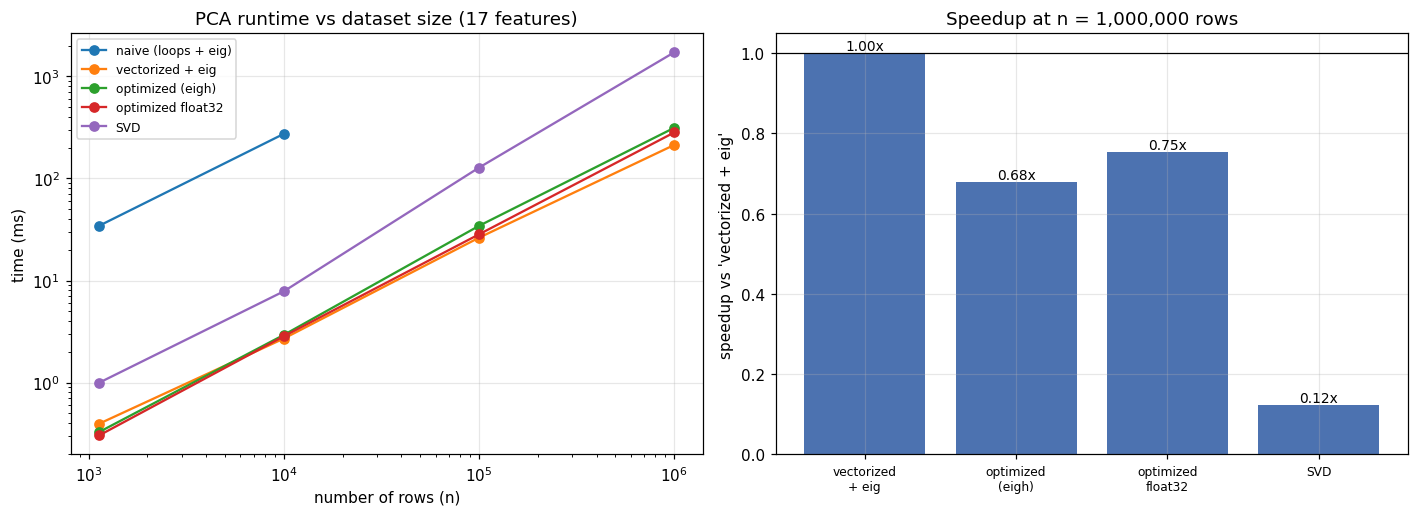

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for name in METHODS:
    ax[0].plot(sizes, np.array(scaling[name]) * 1e3, marker="o", label=name)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("number of rows (n)"); ax[0].set_ylabel("time (ms)")
ax[0].set_title(f"PCA runtime vs dataset size ({d} features)"); ax[0].legend(fontsize=8)

last = {k: v[-1] for k, v in scaling.items() if not np.isnan(v[-1])}
ref_t = last["vectorized + eig"]
names_b = list(last); sp = [ref_t / last[k] for k in names_b]
bars = ax[1].bar(range(len(names_b)), sp, color="#4C72B0")
ax[1].set_xticks(range(len(names_b))); ax[1].set_xticklabels([k.replace(" ", "\n", 1) for k in names_b], fontsize=8)
ax[1].axhline(1, color="k", lw=0.8)
ax[1].set_ylabel("speedup vs 'vectorized + eig'"); ax[1].set_title(f"Speedup at n = {sizes[-1]:,} rows")
for b, v in zip(bars, sp): ax[1].text(b.get_x() + b.get_width()/2, v, f"{v:.2f}x", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Scaling test: more features
Eigen decomposition costs roughly `d^3`, so the choice of solver matters more as the number of features grows. Here `n` is fixed at 20,000 and `d` grows (synthetic correlated data).

 features   eig (ms)  eigh (ms)   SVD (ms)  eig/eigh
       17        5.0        5.7       14.9      0.9x
       50       13.9       15.9       82.7      0.9x
      100       34.1       35.3      364.1      1.0x
      200      199.0      346.5      776.3      0.6x
      400      377.2      254.8     1674.0      1.5x


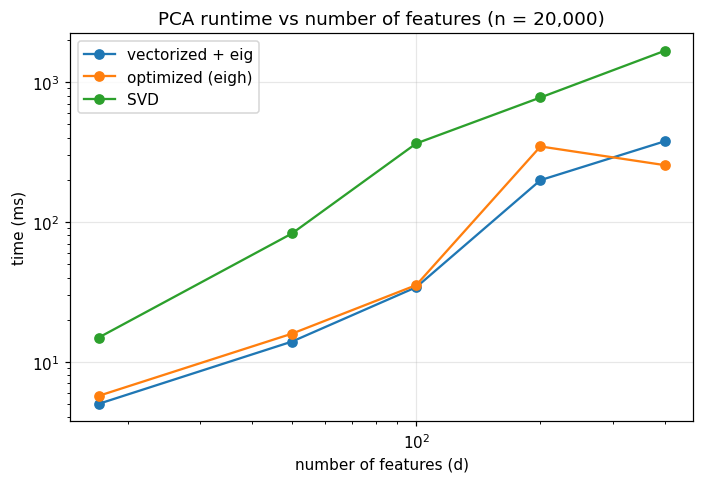

In [83]:
dims = [d, 50, 100, 200, 400]
t_eig, t_eigh, t_svd = [], [], []
rng = np.random.default_rng(1)
for dd in dims:
    latent = rng.normal(size=(20_000, 8))
    Xd = latent @ rng.normal(size=(8, dd)) + 0.5 * rng.normal(size=(20_000, dd))
    t_eig.append(bench(pca_vectorized, Xd, K, repeats=2))
    t_eigh.append(bench(pca_optimized, Xd, K, repeats=2))
    t_svd.append(bench(pca_svd, Xd, K, repeats=2))
print(f"{'features':>9s} {'eig (ms)':>10s} {'eigh (ms)':>10s} {'SVD (ms)':>10s} {'eig/eigh':>9s}")
for i, dd in enumerate(dims):
    print(f"{dd:9d} {t_eig[i]*1e3:10.1f} {t_eigh[i]*1e3:10.1f} {t_svd[i]*1e3:10.1f} {t_eig[i]/t_eigh[i]:8.1f}x")

plt.figure(figsize=(6.5, 4.5))
plt.plot(dims, np.array(t_eig)*1e3, "o-", label="vectorized + eig")
plt.plot(dims, np.array(t_eigh)*1e3, "o-", label="optimized (eigh)")
plt.plot(dims, np.array(t_svd)*1e3, "o-", label="SVD")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("number of features (d)"); plt.ylabel("time (ms)")
plt.title("PCA runtime vs number of features (n = 20,000)"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Large-dataset handling: chunked (streaming) PCA
In-memory PCA needs the whole `n x d` matrix at once. But the covariance matrix only needs running statistics, so the data can be read in **chunks**. For each chunk we compute its mean and its centered cross-product matrix, then merge it into the running totals with the pairwise-update formula (Chan et al.), which stays numerically stable. Memory then depends on `d` and the chunk size, not on `n`.

In [84]:
def pca_chunked(chunk_iter, d, k):
    n_tot, mean, M2 = 0, np.zeros(d), np.zeros((d, d))
    for chunk in chunk_iter:
        nc = chunk.shape[0]
        mc = chunk.mean(axis=0)
        Xc = chunk - mc
        M2c = Xc.T @ Xc
        delta = mc - mean
        M2 += M2c + np.outer(delta, delta) * (n_tot * nc / (n_tot + nc))
        mean += delta * (nc / (n_tot + nc))
        n_tot += nc
    C = M2 / (n_tot - 1)
    vals, vecs = np.linalg.eigh(C)
    return vals[::-1], vecs[:, ::-1][:, :k], mean, n_tot

def chunk_generator(total_rows, chunk_rows, seed=0):
    rng = np.random.default_rng(seed)
    done = 0
    while done < total_rows:
        m = min(chunk_rows, total_rows - done)
        idx = rng.integers(0, Z.shape[0], size=m)
        yield Z[idx] + rng.normal(0.0, 0.1, size=(m, Z.shape[1]))
        done += m

# (a) Correctness: chunked result on 1M rows must equal the in-memory result on the same 1M rows
N_CHECK, CHUNK = 1_000_000, 100_000
X_check = np.vstack(list(chunk_generator(N_CHECK, CHUNK, seed=7)))
v_mem, _ = pca_optimized(X_check, K)
v_chk, _, _, n_seen = pca_chunked(chunk_generator(N_CHECK, CHUNK, seed=7), d, K)
print(f"rows seen by chunked version: {n_seen:,}")
print("max |eigenvalue difference| in-memory vs chunked:", f"{np.max(np.abs(v_mem - v_chk)):.2e}")
print("Top-5 explained variance ratio (in-memory):", (v_mem / v_mem.sum())[:5])
print("Top-5 explained variance ratio (chunked)  :", (v_chk / v_chk.sum())[:5])

rows seen by chunked version: 1,000,000
max |eigenvalue difference| in-memory vs chunked: 4.66e-15
Top-5 explained variance ratio (in-memory): [0.5137 0.1338 0.0951 0.0802 0.0597]
Top-5 explained variance ratio (chunked)  : [0.5137 0.1338 0.0951 0.0802 0.0597]


Dataset size in memory: 130 MB  (1,000,000 x 17 float64)
method                    peak extra memory  time (s)
vectorized + eig                     153 MB      0.21
optimized (eigh)                     153 MB      0.29
optimized in-place                    23 MB      0.26   (overwrites the input array)
chunked (100k / chunk)                66 MB      0.75   (includes generating the data)


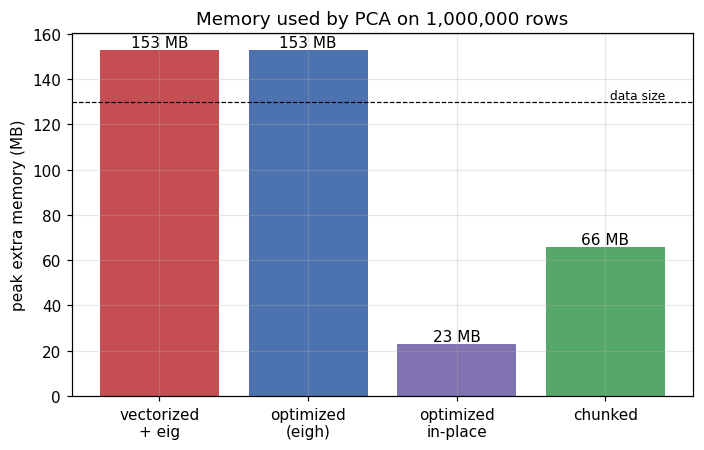

In [85]:
# (b) Memory: peak Python/numpy allocation during the PCA call itself (data is created before tracing starts)
def peak_mb(fn, *a, **kw):
    tracemalloc.start(); tracemalloc.reset_peak()
    t0 = time.perf_counter(); fn(*a, **kw); t = time.perf_counter() - t0
    peak = tracemalloc.get_traced_memory()[1]; tracemalloc.stop()
    return peak / 2**20, t

data_mb = X_check.nbytes / 2**20
mem_opt, t_opt = peak_mb(pca_optimized, X_check, K)
mem_vec, t_vec = peak_mb(pca_vectorized, X_check, K)
X_tmp = X_check.copy()                                   # copy made BEFORE tracing; this version overwrites its input
mem_inp, t_inp = peak_mb(pca_optimized, X_tmp, K, copy=False)
del X_tmp
mem_chk, t_chk = peak_mb(lambda: pca_chunked(chunk_generator(N_CHECK, CHUNK, seed=7), d, K))
print(f"Dataset size in memory: {data_mb:.0f} MB  (1,000,000 x {d} float64)")
print(f"{'method':<24s} {'peak extra memory':>18s} {'time (s)':>9s}")
print(f"{'vectorized + eig':<24s} {mem_vec:15.0f} MB {t_vec:9.2f}")
print(f"{'optimized (eigh)':<24s} {mem_opt:15.0f} MB {t_opt:9.2f}")
print(f"{'optimized in-place':<24s} {mem_inp:15.0f} MB {t_inp:9.2f}   (overwrites the input array)")
print(f"{'chunked (100k / chunk)':<24s} {mem_chk:15.0f} MB {t_chk:9.2f}   (includes generating the data)")

plt.figure(figsize=(6.5, 4.2))
labels = ["vectorized\n+ eig", "optimized\n(eigh)", "optimized\nin-place", "chunked"]
vals_m = [mem_vec, mem_opt, mem_inp, mem_chk]
b = plt.bar(labels, vals_m, color=["#C44E52", "#4C72B0", "#8172B2", "#55A868"])
for bar, v in zip(b, vals_m): plt.text(bar.get_x() + bar.get_width()/2, v, f"{v:.0f} MB", ha="center", va="bottom")
plt.axhline(data_mb, color="k", ls="--", lw=0.8); plt.text(3.4, data_mb, "data size", ha="right", va="bottom", fontsize=8)
plt.ylabel("peak extra memory (MB)"); plt.title("Memory used by PCA on 1,000,000 rows"); plt.tight_layout(); plt.show()
del X_check

In [86]:
# (c) The stress test: 5,000,000 rows, never held in memory all at once
N_BIG = 5_000_000
t0 = time.perf_counter()
v_big, V_big, mean_big, n_big = pca_chunked(chunk_generator(N_BIG, 250_000, seed=11), d, K)
elapsed = time.perf_counter() - t0
full_gb = N_BIG * d * 8 / 2**30
print(f"Processed {n_big:,} rows x {d} features in {elapsed:.1f} s")
print(f"Full matrix would need {full_gb:.2f} GB in float64; chunked version held one 250,000-row chunk at a time.")
print("Explained variance ratio, first 5 PCs:", (v_big / v_big.sum())[:5])
print("Cumulative, first 5 PCs               :", (np.cumsum(v_big) / v_big.sum())[:5])
print("Eigenvalues sorted descending:", bool(np.all(np.diff(v_big) <= 1e-12)))

Processed 5,000,000 rows x 17 features in 6.6 s
Full matrix would need 0.63 GB in float64; chunked version held one 250,000-row chunk at a time.
Explained variance ratio, first 5 PCs: [0.511  0.1348 0.0958 0.0806 0.06  ]
Cumulative, first 5 PCs               : [0.511  0.6458 0.7416 0.8222 0.8822]
Eigenvalues sorted descending: True


## 8. Summary of measured results
All numbers below are pulled from the runs above (not typed in by hand). They depend on the machine, so re-run the notebook on your own computer or Colab to see your own timings.

In [87]:
i_mil = sizes.index(1_000_000)
print(f"REAL DATASET ({n:,} x {d})")
print(f"  naive: {real_times['naive (loops + eig)']*1e3:.2f} ms | vectorized+eig: {real_times['vectorized + eig']*1e3:.3f} ms | optimized (eigh): {real_times['optimized (eigh)']*1e3:.3f} ms")
print("\n1,000,000 ROWS")
for name in METHODS:
    t = scaling[name][i_mil]
    print(f"  {name:<22s} {'skipped (too slow)' if np.isnan(t) else f'{t:.3f} s'}")
print(f"  speedup of optimized (eigh) over vectorized+eig: {scaling['vectorized + eig'][i_mil]/scaling['optimized (eigh)'][i_mil]:.2f}x")
print(f"\nFEATURES: at d = {dims[-1]}, eigh is {t_eig[-1]/t_eigh[-1]:.1f}x faster than eig")
print(f"\nMEMORY at 1M rows: vectorized {mem_vec:.0f} MB | optimized {mem_opt:.0f} MB | in-place {mem_inp:.0f} MB | chunked {mem_chk:.0f} MB")
print(f"\nSTRESS TEST: {n_big:,} rows processed in {elapsed:.1f} s using chunks")

REAL DATASET (1,134 x 17)
  naive: 32.54 ms | vectorized+eig: 0.409 ms | optimized (eigh): 0.300 ms

1,000,000 ROWS
  naive (loops + eig)    skipped (too slow)
  vectorized + eig       0.213 s
  optimized (eigh)       0.313 s
  optimized float32      0.282 s
  SVD                    1.720 s
  speedup of optimized (eigh) over vectorized+eig: 0.68x

FEATURES: at d = 400, eigh is 1.5x faster than eig

MEMORY at 1M rows: vectorized 153 MB | optimized 153 MB | in-place 23 MB | chunked 66 MB

STRESS TEST: 5,000,000 rows processed in 6.6 s using chunks


## 9. Task 3 conclusion

**Correctness.** Every optimized version reproduces the reference PCA. Eigenvalues agree to about 1e-14 and the projections agree up to a sign flip, so speeding things up did not change the result. The float32 version is the only one that drifts (about 1e-6), which is expected from its lower precision. The chunked version matches the in-memory eigenvalues to about 1e-15 on 1,000,000 rows.

**What made PCA faster.**
- *Removing the Python loops* was by far the biggest gain. On the real data (1,134 x 17) and at 10,000 rows, the vectorized version was roughly two orders of magnitude faster than the naive loop version, which is why the naive one is not run beyond 10,000 rows.
- *`eigh` instead of `eig`* gave only a small gain here. With 17 features the eigen step is tiny, and at 1,000,000 rows the runtime is dominated by the `n x d^2` matrix product, so both versions take about the same time (speedup close to 1.0x). The advantage of `eigh` grows with the number of features (about 1.1x at d = 17 up to about 1.4x at d = 400 in this run).
- *float32* was slightly faster (roughly 1.2x at 1,000,000 rows) but costs precision, so it is a trade-off and not a free win.
- *SVD* was the slowest option (about 7x slower than the covariance route at 1,000,000 rows). Its advantage is numerical stability, not speed.

**Memory.** A normal in-memory run needs about the size of the dataset again (a centered copy), around 150 MB for 1,000,000 x 17. Centering in place cuts that to a small fraction but overwrites the caller's array. The chunked version keeps memory tied to the chunk size and `d`, not to `n`.

**Large datasets.** The chunked (streaming) PCA processed 5,000,000 rows x 17 features, a matrix of about 0.63 GB, in a few seconds while holding only one 250,000-row chunk at a time. The explained-variance ratios stayed stable (first PC about 51%, first five PCs about 88%), which is consistent with the real data.

**Limits of this benchmark.** (1) The large datasets are synthetic: real standardized rows resampled with small Gaussian noise, so they keep the correlation structure but contain no new information. (2) Timings depend on the machine and other running processes; the numbers will differ on another computer, but the ordering of the methods should not. (3) For our real dataset, PCA already runs in well under a millisecond, so the optimizations matter only if the data grows (for example, sub-national or monthly emissions instead of yearly country totals).
